In [1]:
import numpy as np
import matplotlib.pyplot as plt

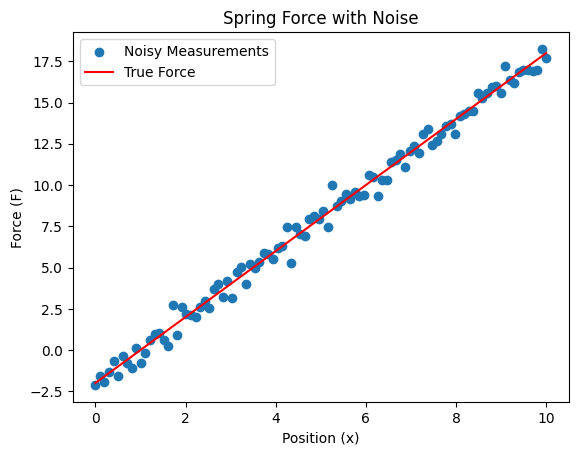

In [11]:
def elastic_force(x, k, x0):
    return k * (x - x0)

def simulate_spring(k, x0, num_points=100, noise_std=0.5):
    x = np.linspace(0, 10, num_points)
    force = elastic_force(x, k, x0)
    noise = np.random.normal(0, noise_std, size=force.shape) # Add noise to the force measurements
    return x, force + noise

# Parameters for the spring
k_true = 2.0  # Spring constant
x0_true = 1.0  # Rest position  
x, force_measurements = simulate_spring(k_true, x0_true)

plt.scatter(x, force_measurements, label='Noisy Measurements')
plt.plot(x, elastic_force(x, k_true, x0_true), label='True Force', color='red')
plt.xlabel('Position (x)')
plt.ylabel('Force (F)')
plt.title('Spring Force with Noise')
plt.legend()
plt.show()

Running MCMC...


100%|██████████| 5000/5000 [00:01<00:00, 4116.98it/s]


Done.

True  values :  k = 3.500 N/m,  sigma = 0.800 N
MCMC  median :  k = 3.594 N/m  [3.498, 3.690]  (1σ credible interval)
MCMC  median :  sigma = 0.626 N  [0.552, 0.720]


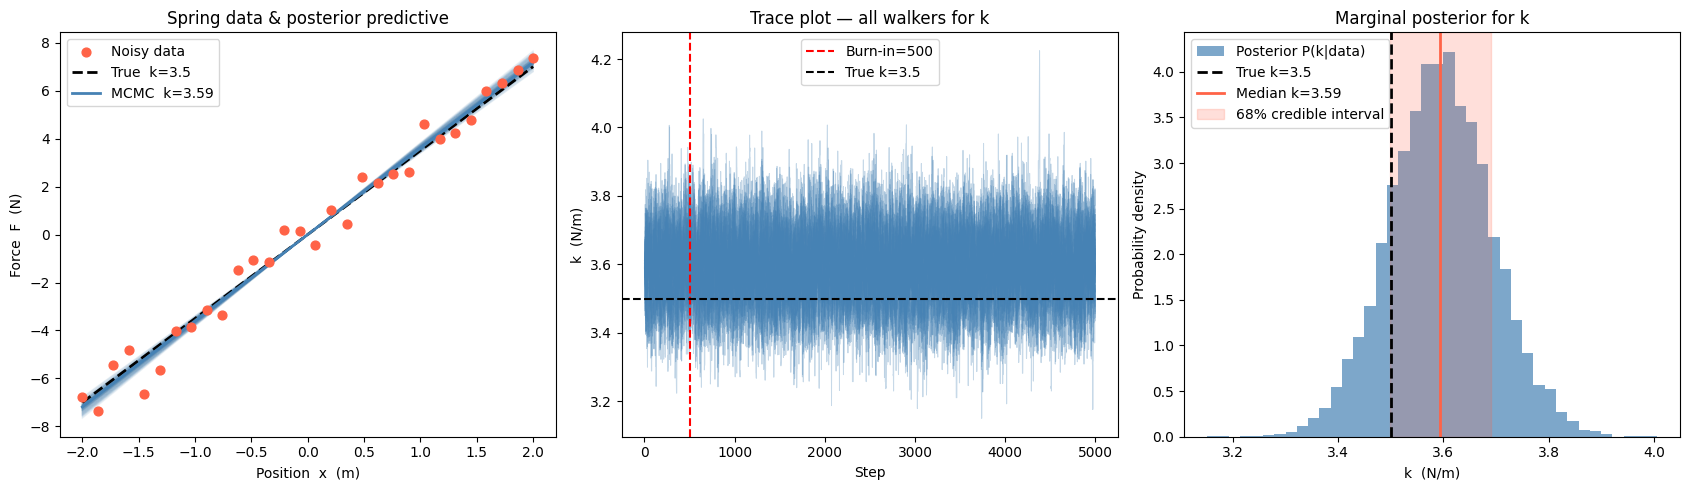

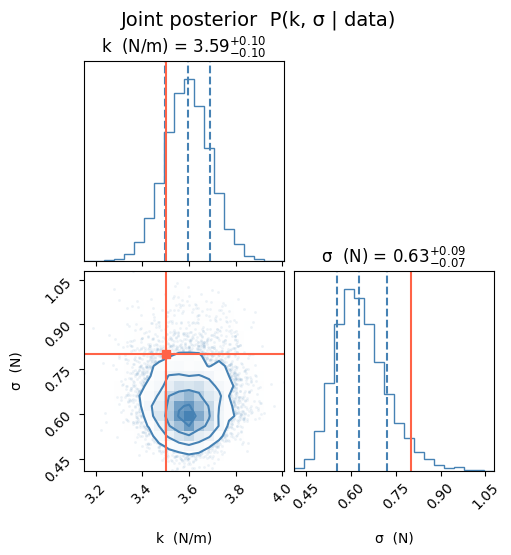


Plots saved.


In [13]:
# let's try to recover the linear behavior with MCMC sampling
"""
MCMC Sampling to Recover Spring Constant (Hooke's Law)
=======================================================
Model:  F = k * x   (Hooke's law, F = -kx but we absorb the sign into k)
        Observed data has Gaussian noise: F_obs ~ N(k*x, sigma^2)

We use emcee (affine-invariant ensemble sampler) to find the posterior:
    P(k, sigma | data) ∝ P(data | k, sigma) * P(k, sigma)
                               likelihood        prior

Install dependencies:
    pip install numpy matplotlib emcee corner
"""

import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

# ── Reproducibility ──────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

# ── 1. Simulate spring data ───────────────────────────────────────────────────
TRUE_K     = 3.5          # N/m  — what we want MCMC to recover
TRUE_SIGMA = 0.8          # measurement noise std (N)
N_POINTS   = 30

x_data = np.linspace(-2.0, 2.0, N_POINTS)            # positions (m)
F_clean = TRUE_K * x_data                             # ideal Hooke's law
F_data  = F_clean + rng.normal(0, TRUE_SIGMA, N_POINTS)   # noisy observations

# ── 2. Define the probabilistic model ─────────────────────────────────────────

def log_prior(theta):
    """
    Prior P(theta).  We use weakly-informative priors:
      k     ~ Uniform(0, 20)   — spring constant must be positive
      sigma ~ Uniform(0, 10)   — noise std must be positive

    Returns log P(theta).  Returns -inf if params are outside prior support
    (this is how we enforce hard bounds in log-space).
    """
    k, sigma = theta
    if 0 < k < 20 and 0 < sigma < 10:
        return 0.0          # log(1) = 0  →  flat / uniform prior
    return -np.inf          # log(0) = -inf  →  zero probability


def log_likelihood(theta, x, F_obs):
    """
    Likelihood P(data | theta).
    Assumes independent Gaussian noise on each measurement:
        F_obs[i] ~ Normal(k * x[i], sigma^2)

    log L = sum_i  log[ (1/sqrt(2π σ²)) * exp(-(F_obs - k*x)² / 2σ²) ]
          = -N/2 * log(2π) - N*log(σ) - (1/2σ²) * sum((F_obs - k*x)²)
    """
    k, sigma = theta
    F_model  = k * x
    residuals = F_obs - F_model
    return -0.5 * np.sum(residuals**2 / sigma**2 + np.log(2 * np.pi * sigma**2))


def log_posterior(theta, x, F_obs):
    """
    Posterior (unnormalized):  log P(theta|data) = log P(data|theta) + log P(theta)
    This is all MCMC needs — the normalizing constant P(data) cancels out.
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf          # outside prior: reject immediately
    return lp + log_likelihood(theta, x, F_obs)


# ── 3. Run MCMC with emcee ────────────────────────────────────────────────────

N_DIM     = 2       # parameters: [k, sigma]
N_WALKERS = 32      # ensemble of parallel walkers (must be even, >= 2*ndim)
N_STEPS   = 5000    # steps per walker (first ~500 will be burn-in)
BURN_IN   = 500     # steps to discard as the chain "warms up"

# Initialise walkers near a reasonable starting point with small scatter
# (perturbing around a least-squares estimate is good practice)
k_init     = np.polyfit(x_data, F_data, 1)[0]   # quick linear regression
sigma_init = np.std(F_data - k_init * x_data)

p0 = np.array([k_init, sigma_init]) + 1e-2 * rng.standard_normal((N_WALKERS, N_DIM))
p0[:, 1] = np.abs(p0[:, 1])   # ensure sigma > 0

sampler = emcee.EnsembleSampler(
    N_WALKERS, N_DIM, log_posterior, args=(x_data, F_data)
)

print("Running MCMC...")
sampler.run_mcmc(p0, N_STEPS, progress=True)
print("Done.\n")

# Flatten chain, discarding burn-in
flat_samples = sampler.get_chain(discard=BURN_IN, thin=15, flat=True)
# thin=15: keep every 15th sample to reduce autocorrelation

# ── 4. Results ────────────────────────────────────────────────────────────────

k_mcmc, sigma_mcmc = np.median(flat_samples, axis=0)
k_lo, k_hi         = np.percentile(flat_samples[:, 0], [16, 84])
s_lo, s_hi         = np.percentile(flat_samples[:, 1], [16, 84])

print(f"True  values :  k = {TRUE_K:.3f} N/m,  sigma = {TRUE_SIGMA:.3f} N")
print(f"MCMC  median :  k = {k_mcmc:.3f} N/m  [{k_lo:.3f}, {k_hi:.3f}]  (1σ credible interval)")
print(f"MCMC  median :  sigma = {sigma_mcmc:.3f} N  [{s_lo:.3f}, {s_hi:.3f}]")

# ── 5. Plots ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- (a) Data + fitted line ---------------------------------------------------
ax = axes[0]
x_line = np.linspace(x_data.min(), x_data.max(), 200)

# Draw 200 random posterior samples as faint lines (posterior predictive)
for s in flat_samples[rng.integers(len(flat_samples), size=200)]:
    ax.plot(x_line, s[0] * x_line, color="steelblue", alpha=0.05, lw=1)

ax.scatter(x_data, F_data, color="tomato", zorder=5, label="Noisy data", s=40)
ax.plot(x_line, TRUE_K * x_line,    "k--",  lw=2, label=f"True  k={TRUE_K}")
ax.plot(x_line, k_mcmc * x_line, "steelblue", lw=2,
        label=f"MCMC  k={k_mcmc:.2f}")
ax.set_xlabel("Position  x  (m)")
ax.set_ylabel("Force  F  (N)")
ax.set_title("Spring data & posterior predictive")
ax.legend()

# --- (b) Trace plot (walker paths) -------------------------------------------
ax = axes[1]
chain = sampler.get_chain()   # shape: (steps, walkers, ndim)
for i in range(N_WALKERS):
    ax.plot(chain[:, i, 0], alpha=0.3, lw=0.7, color="steelblue")
ax.axvline(BURN_IN, color="red", lw=1.5, ls="--", label=f"Burn-in={BURN_IN}")
ax.axhline(TRUE_K,  color="black", lw=1.5, ls="--", label=f"True k={TRUE_K}")
ax.set_xlabel("Step")
ax.set_ylabel("k  (N/m)")
ax.set_title("Trace plot — all walkers for k")
ax.legend()

# --- (c) Posterior histogram for k -------------------------------------------
ax = axes[2]
ax.hist(flat_samples[:, 0], bins=40, color="steelblue", alpha=0.7,
        density=True, label="Posterior P(k|data)")
ax.axvline(TRUE_K,   color="black", lw=2, ls="--", label=f"True k={TRUE_K}")
ax.axvline(k_mcmc,   color="tomato", lw=2, label=f"Median k={k_mcmc:.2f}")
ax.axvspan(k_lo, k_hi, alpha=0.2, color="tomato", label="68% credible interval")
ax.set_xlabel("k  (N/m)")
ax.set_ylabel("Probability density")
ax.set_title("Marginal posterior for k")
ax.legend()

plt.tight_layout()
plt.savefig("mcmc_spring_results.png", dpi=150)
plt.show()

# --- Corner plot: joint posterior of all parameters --------------------------
fig2 = corner.corner(
    flat_samples,
    labels=["k  (N/m)", "σ  (N)"],
    truths=[TRUE_K, TRUE_SIGMA],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    truth_color="tomato",
    color="steelblue",
)
fig2.suptitle("Joint posterior  P(k, σ | data)", y=1.02, fontsize=14)
plt.savefig("mcmc_spring_corner.png", dpi=150)
plt.show()

print("\nPlots saved.")


NOT sure SBI is working correctly, it was mostly claude trying to implement what we did in the tutorial. The reason why I sayv that something does not feel right is that the spread of SBI posteriors is still very large

PART 1: Running MCMC …


100%|██████████| 5000/5000 [00:01<00:00, 3868.15it/s]



MCMC:  k = 3.591 N/m,  sigma = 0.621 N
       (true: 3.5, 0.8)

PART 2: SBI — Neural Posterior Estimation (NPE)

Generating 10000 simulations …


100%|██████████| 10000/10000 [00:00<00:00, 160371.96it/s]


Simulated theta shape : torch.Size([10000, 2])
Simulated x shape     : torch.Size([10000, 50])

Training NPE …
 Neural network successfully converged after 87 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 87
        Best validation performance: 0.1159
        -------------------------
        


Drawing 10000 posterior samples: 10065it [00:00, 370852.91it/s]           


SBI/NPE: k = 3.562 N/m,  sigma = 0.715 N
         (true: 3.5, 0.8)


Plotting …


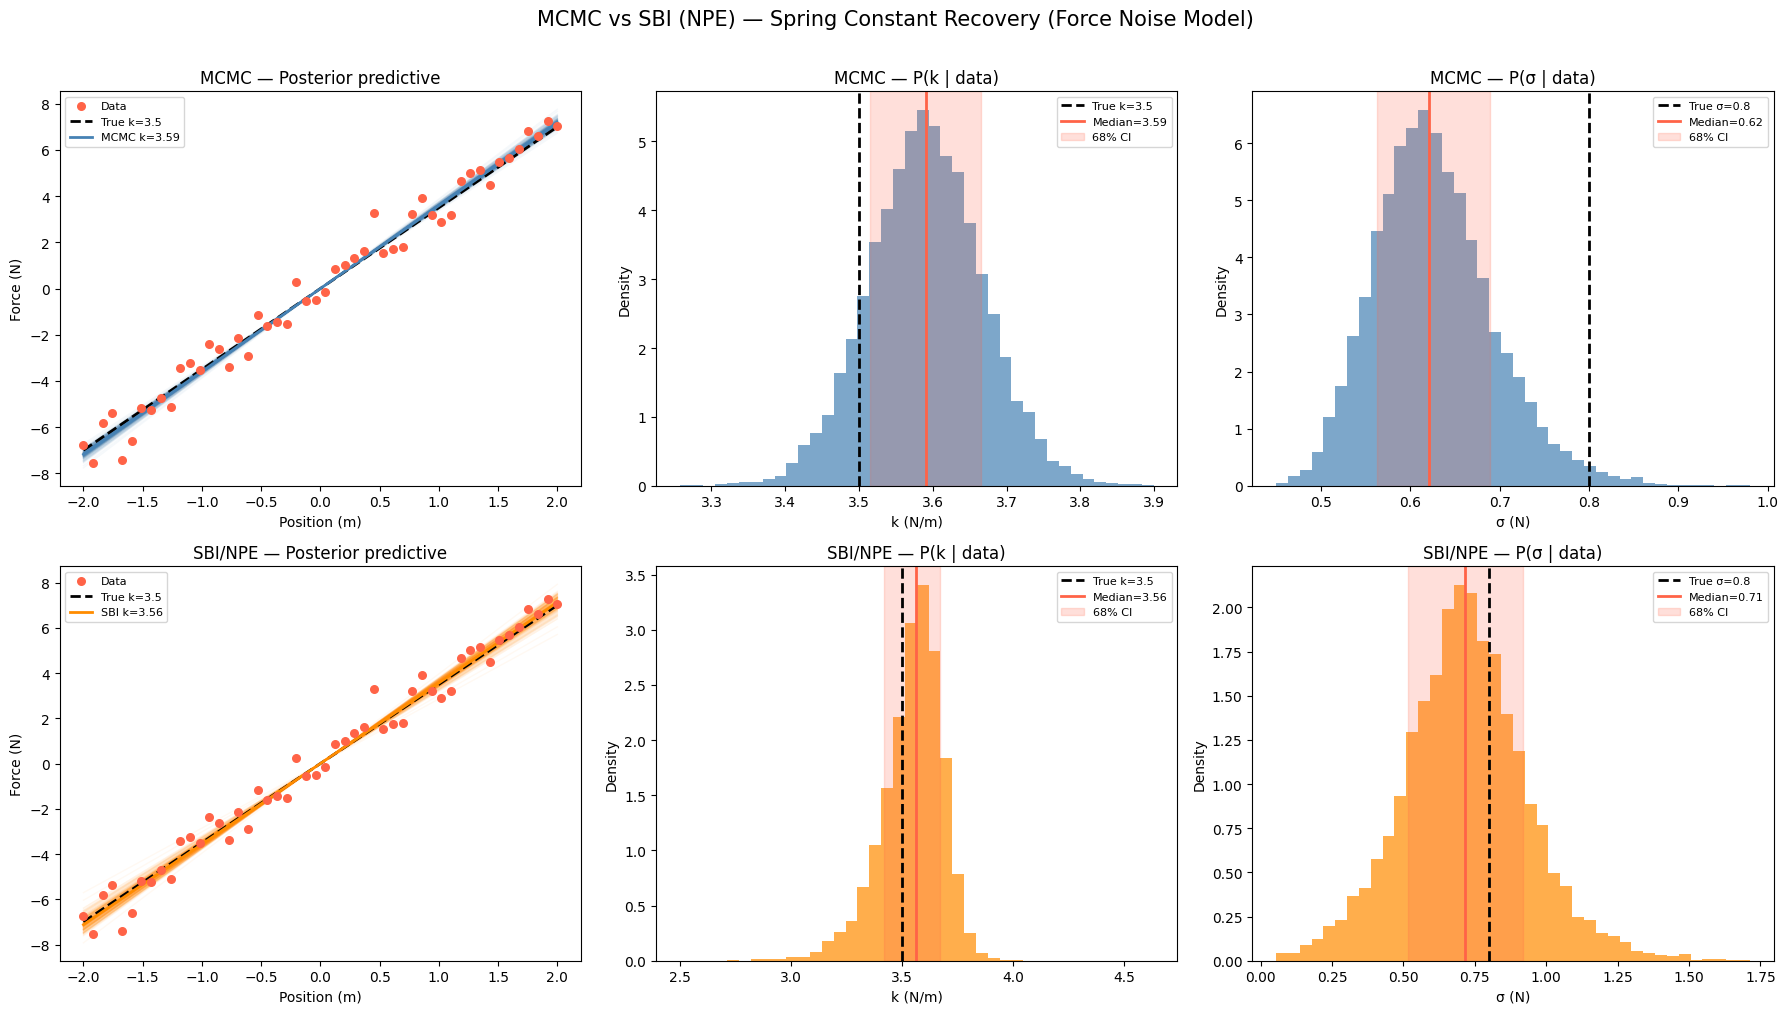

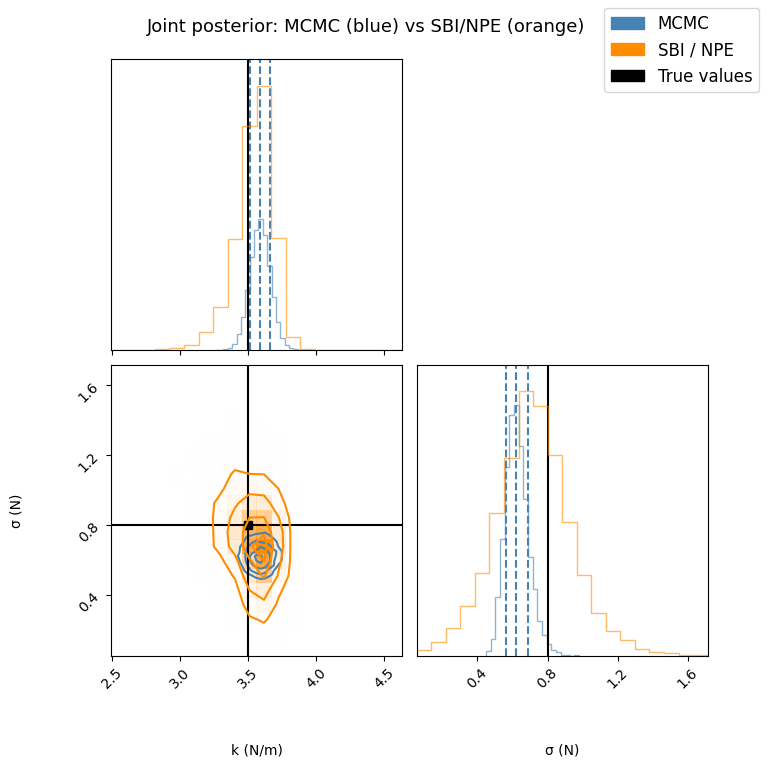


All plots saved.

── Final comparison (Force Noise Model) ────────────────────
Method       k median   σ median
True            3.500      0.800
MCMC            3.591      0.621
SBI/NPE         3.562      0.715


In [6]:
"""
Spring Parameter Recovery with MCMC and SBI — Class Implementation
===================================================================

Unified interface for recovering spring parameters using both MCMC and SBI/NPE.

NOISE MODEL: Force Noise (constant measurement error)
  F_obs = k*x + σ*ε,  where ε ~ N(0,1)
  => F_obs ~ N(k*x, σ²)

Usage:
    study = SpringInferenceComparison(
        n_points=50,
        n_simulations=10000,
        noise_std=0.8
    )
    study.run_all()
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
import emcee, corner
from sbi import utils as sbi_utils
from sbi.inference import NPE, simulate_for_sbi
from matplotlib.patches import Patch


class SpringInferenceComparison:
    """
    Unified interface for comparing MCMC and SBI/NPE on spring constant recovery.
    
    Noise Model: F_obs = k*x + σ*ε  (force noise, constant measurement error)
    
    Attributes:
        n_points : int
            Number of measurement positions
        n_simulations : int
            Number of simulations for SBI training
        noise_std : float
            Standard deviation of force measurement noise
        true_k : float
            True spring constant (N/m)
        true_sigma : float
            True force measurement noise std (N)
    """
    
    def __init__(self, n_points=50, n_simulations=10000, noise_std=0.8,
                 true_k=3.5, true_sigma=0.8, seed=42,
                 n_walkers=32, n_steps=5000, burn_in=500, n_posterior=10000):
        """
        Initialize the Spring Parameter Recovery study.
        
        Parameters:
        -----------
        n_points : int, default=50
            Number of measurement points (spatial positions)
        n_simulations : int, default=10000
            Number of simulations to generate for SBI training
        noise_std : float, default=0.8
            Standard deviation of force measurement noise (N)
        true_k : float, default=3.5
            True spring constant (N/m)
        true_sigma : float, default=0.8
            True force measurement noise std (N)
        seed : int, default=42
            Random seed for reproducibility
        n_walkers : int, default=32
            Number of MCMC walkers (must be even, >= 2*ndim)
        n_steps : int, default=5000
            Number of MCMC steps per walker
        burn_in : int, default=500
            Number of burn-in steps to discard from MCMC
        n_posterior : int, default=5000
            Number of posterior samples to draw from SBI
        """
        # Store parameters
        self.n_points = n_points
        self.n_simulations = n_simulations
        self.noise_std = noise_std
        self.true_k = true_k
        self.true_sigma = true_sigma
        self.seed = seed
        self.n_walkers = n_walkers
        self.n_steps = n_steps
        self.burn_in = burn_in
        self.n_posterior = n_posterior
        
        # Initialize random seeds
        self.rng = np.random.default_rng(seed)
        torch.manual_seed(seed)
        
        # Create measurement positions and observed data
        self.x_positions = np.linspace(-2.0, 2.0, n_points)
        self.F_observed = self._generate_observed_data()
        
        # Results storage
        self.mcmc_samples = None
        self.sbi_samples_np = None
        self.k_mcmc = None
        self.s_mcmc = None
        self.k_sbi = None
        self.s_sbi = None
        self.posterior = None
        
    def _generate_observed_data(self):
        """
        Generate synthetic noisy force measurements.
        Model: F_obs = k*x + σ*ε,  ε ~ N(0,1)
        """
        F_clean = self.true_k * self.x_positions
        force_noise = self.rng.normal(0, self.noise_std, self.n_points)
        return F_clean + force_noise
    
    def _log_prior_mcmc(self, theta):
        """Prior P(theta) for MCMC: uniform box prior."""
        k, sigma = theta
        return 0.0 if (0 < k < 20 and 0 < sigma < 10) else -np.inf
    
    def _log_likelihood_mcmc(self, theta, x, F_obs):
        """
        Likelihood P(data | theta) for FORCE NOISE model.
        Assumes: F_obs ~ N(k*x, σ²)  (constant force measurement error)
        """
        k, sigma = theta
        if sigma <= 0:
            return -np.inf
        F_model = k * x
        residuals = F_obs - F_model
        # log N(residuals; 0, σ²) = -0.5*sum[(residuals/σ)² + log(2πσ²)]
        return -0.5 * np.sum(residuals**2 / sigma**2 + np.log(2 * np.pi * sigma**2))
    
    def _log_posterior_mcmc(self, theta, x, F_obs):
        """Unnormalized posterior log P(theta|data)."""
        lp = self._log_prior_mcmc(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + self._log_likelihood_mcmc(theta, x, F_obs)
    
    def run_mcmc(self, verbose=True):
        """
        Run MCMC sampling to recover spring parameters.
        
        Parameters:
        -----------
        verbose : bool, default=True
            Print progress and results
        """
        if verbose:
            print("=" * 60)
            print("PART 1: Running MCMC …")
            print("=" * 60)
        
        # Initialize walkers near a reasonable starting point
        k0 = np.polyfit(self.x_positions, self.F_observed, 1)[0]
        sig0 = np.std(self.F_observed - k0 * self.x_positions)
        p0 = np.array([k0, sig0]) + 1e-2 * self.rng.standard_normal((self.n_walkers, 2))
        p0[:, 0] = np.abs(p0[:, 0])
        p0[:, 1] = np.abs(p0[:, 1])
        
        # Run ensemble sampler
        sampler = emcee.EnsembleSampler(
            self.n_walkers, 2, self._log_posterior_mcmc,
            args=(self.x_positions, self.F_observed)
        )
        sampler.run_mcmc(p0, self.n_steps, progress=verbose)
        
        # Extract flattened samples
        self.mcmc_samples = sampler.get_chain(discard=self.burn_in, thin=15, flat=True)
        self.k_mcmc = np.median(self.mcmc_samples[:, 0])
        self.s_mcmc = np.median(self.mcmc_samples[:, 1])
        
        if verbose:
            print(f"\nMCMC:  k = {self.k_mcmc:.3f} N/m,  sigma = {self.s_mcmc:.3f} N")
            print(f"       (true: {self.true_k}, {self.true_sigma})\n")
    
    def run_sbi(self, verbose=True):
        """
        Run SBI/NPE training and sample from posterior.
        
        Parameters:
        -----------
        verbose : bool, default=True
            Print progress and results
        """
        if verbose:
            print("=" * 60)
            print("PART 2: SBI — Neural Posterior Estimation (NPE)")
            print("=" * 60)
        
        # Step 1: Define prior
        prior = sbi_utils.BoxUniform(
            low=torch.tensor([0.0, 0.05]),
            high=torch.tensor([8.0, 3.0])
        )
        
        # Step 2: Define simulator with FORCE NOISE model
        x_torch = torch.tensor(self.x_positions, dtype=torch.float32)
        
        def spring_simulator(theta):
            """
            Simulator for force measurements.
            Model: F = k*x + σ*ε,  ε ~ N(0,1)
            """
            if theta.dim() == 1:
                theta = theta.unsqueeze(0)
            
            k = theta[:, 0]
            sigma = theta[:, 1]
            
            # F_clean: (batch, n_points)
            # noise: (batch, n_points)
            # F_sim: (batch, n_points)
            F_clean = k.unsqueeze(1) * x_torch.unsqueeze(0)
            F_sim = F_clean + sigma.unsqueeze(1) * torch.randn(theta.shape[0], self.n_points)
            
            return F_sim
        
        # Step 3: Generate simulations
        if verbose:
            print(f"\nGenerating {self.n_simulations} simulations …")
        
        theta_sim, x_sim = simulate_for_sbi(
            simulator=spring_simulator,
            proposal=prior,
            num_simulations=self.n_simulations,
        )
        if verbose:
            print(f"Simulated theta shape : {theta_sim.shape}")
            print(f"Simulated x shape     : {x_sim.shape}")
        
        # Step 4: Train neural density estimator
        if verbose:
            print("\nTraining NPE …")
        
        inference = NPE(prior=prior)
        density_estimator = inference.append_simulations(theta_sim, x_sim).train(show_train_summary=verbose)
        '''
        density_estimator = inference.train(
            training_batch_size=256,
            max_num_epochs=200,
            show_train_summary=verbose,
        )
        '''
        # Step 5: Build posterior and sample
        self.posterior = inference.build_posterior(density_estimator)
        x_obs_torch = torch.tensor(self.F_observed, dtype=torch.float32)
        
        sbi_samples = self.posterior.sample(
            (self.n_posterior,),
            x=x_obs_torch,
        )
        self.sbi_samples_np = sbi_samples.numpy()
        self.k_sbi = np.median(self.sbi_samples_np[:, 0])
        self.s_sbi = np.median(self.sbi_samples_np[:, 1])
        
        if verbose:
            print(f"\nSBI/NPE: k = {self.k_sbi:.3f} N/m,  sigma = {self.s_sbi:.3f} N")
            print(f"         (true: {self.true_k}, {self.true_sigma})\n")
    
    def plot_comparison(self, figsize=(18, 10)):
        """
        Generate side-by-side comparison plots of MCMC and SBI results.
        
        Parameters:
        -----------
        figsize : tuple, default=(18, 10)
            Figure size (width, height)
        """
        if self.mcmc_samples is None or self.sbi_samples_np is None:
            raise ValueError("Must run run_mcmc() and run_sbi() first")
        
        print("\nPlotting …")
        
        x_line = np.linspace(self.x_positions.min(), self.x_positions.max(), 200)
        
        # Main comparison figure
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle("MCMC vs SBI (NPE) — Spring Constant Recovery (Force Noise Model)", fontsize=15, y=1.01)
        
        # ── Row 1: MCMC ────────────────────────────────────────────────────────
        # (a) Posterior predictive
        ax = axes[0, 0]
        mcmc_draw = self.mcmc_samples[self.rng.integers(len(self.mcmc_samples), size=200)]
        for s in mcmc_draw:
            ax.plot(x_line, s[0] * x_line, color="steelblue", alpha=0.05, lw=1)
        ax.scatter(self.x_positions, self.F_observed, color="tomato", zorder=5, s=30, label="Data")
        ax.plot(x_line, self.true_k * x_line, "k--", lw=2, label=f"True k={self.true_k}")
        ax.plot(x_line, self.k_mcmc * x_line, "steelblue", lw=2, label=f"MCMC k={self.k_mcmc:.2f}")
        ax.set(xlabel="Position (m)", ylabel="Force (N)", title="MCMC — Posterior predictive")
        ax.legend(fontsize=8)
        
        # (b) Marginal posterior for k
        ax = axes[0, 1]
        ax.hist(self.mcmc_samples[:, 0], bins=40, density=True, color="steelblue", alpha=0.7)
        ax.axvline(self.true_k, color="black", lw=2, ls="--", label=f"True k={self.true_k}")
        ax.axvline(self.k_mcmc, color="tomato", lw=2, label=f"Median={self.k_mcmc:.2f}")
        lo, hi = np.percentile(self.mcmc_samples[:, 0], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="k (N/m)", ylabel="Density", title="MCMC — P(k | data)")
        ax.legend(fontsize=8)
        
        # (c) Marginal posterior for sigma
        ax = axes[0, 2]
        ax.hist(self.mcmc_samples[:, 1], bins=40, density=True, color="steelblue", alpha=0.7)
        ax.axvline(self.true_sigma, color="black", lw=2, ls="--", label=f"True σ={self.true_sigma}")
        ax.axvline(self.s_mcmc, color="tomato", lw=2, label=f"Median={self.s_mcmc:.2f}")
        lo, hi = np.percentile(self.mcmc_samples[:, 1], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="σ (N)", ylabel="Density", title="MCMC — P(σ | data)")
        ax.legend(fontsize=8)
        
        # ── Row 2: SBI ─────────────────────────────────────────────────────────
        # (d) Posterior predictive
        pp_samples = self.sbi_samples_np[self.rng.integers(self.n_posterior, size=200)]
        ax = axes[1, 0]
        for s in pp_samples:
            ax.plot(x_line, s[0] * x_line, color="darkorange", alpha=0.05, lw=1)
        ax.scatter(self.x_positions, self.F_observed, color="tomato", zorder=5, s=30, label="Data")
        ax.plot(x_line, self.true_k * x_line, "k--", lw=2, label=f"True k={self.true_k}")
        ax.plot(x_line, self.k_sbi * x_line, "darkorange", lw=2, label=f"SBI k={self.k_sbi:.2f}")
        ax.set(xlabel="Position (m)", ylabel="Force (N)", title="SBI/NPE — Posterior predictive")
        ax.legend(fontsize=8)
        
        # (e) Marginal posterior for k
        ax = axes[1, 1]
        ax.hist(self.sbi_samples_np[:, 0], bins=40, density=True, color="darkorange", alpha=0.7)
        ax.axvline(self.true_k, color="black", lw=2, ls="--", label=f"True k={self.true_k}")
        ax.axvline(self.k_sbi, color="tomato", lw=2, label=f"Median={self.k_sbi:.2f}")
        lo, hi = np.percentile(self.sbi_samples_np[:, 0], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="k (N/m)", ylabel="Density", title="SBI/NPE — P(k | data)")
        ax.legend(fontsize=8)
        
        # (f) Marginal posterior for sigma
        ax = axes[1, 2]
        ax.hist(self.sbi_samples_np[:, 1], bins=40, density=True, color="darkorange", alpha=0.7)
        ax.axvline(self.true_sigma, color="black", lw=2, ls="--", label=f"True σ={self.true_sigma}")
        ax.axvline(self.s_sbi, color="tomato", lw=2, label=f"Median={self.s_sbi:.2f}")
        lo, hi = np.percentile(self.sbi_samples_np[:, 1], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="σ (N)", ylabel="Density", title="SBI/NPE — P(σ | data)")
        ax.legend(fontsize=8)
        
        plt.tight_layout()
        plt.savefig("sbi_vs_mcmc_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()
        
        # Corner plot: MCMC vs SBI overlaid
        fig2, axes2 = plt.subplots(2, 2, figsize=(8, 8))
        labels = ["k (N/m)", "σ (N)"]
        corner.corner(
            self.mcmc_samples, labels=labels, fig=fig2,
            color="steelblue", truths=[self.true_k, self.true_sigma],
            truth_color="black", quantiles=[0.16, 0.5, 0.84],
            plot_density=True, plot_datapoints=False,
            hist_kwargs={"alpha": 0.6},
        )
        corner.corner(
            self.sbi_samples_np, labels=labels, fig=fig2,
            color="darkorange",
            plot_density=True, plot_datapoints=False,
            hist_kwargs={"alpha": 0.6},
        )
        fig2.legend(
            handles=[Patch(color="steelblue", label="MCMC"),
                     Patch(color="darkorange", label="SBI / NPE"),
                     Patch(color="black", label="True values")],
            loc="upper right", fontsize=12
        )
        fig2.suptitle("Joint posterior: MCMC (blue) vs SBI/NPE (orange)", fontsize=13)
        plt.savefig("sbi_vs_mcmc_corner.png", dpi=150, bbox_inches="tight")
        plt.show()
        
        print("\nAll plots saved.")
    
    def print_summary(self):
        """Print summary of results."""
        if self.k_mcmc is None or self.k_sbi is None:
            raise ValueError("Must run run_mcmc() and run_sbi() first")
        
        print("\n── Final comparison (Force Noise Model) ────────────────────")
        print(f"{'Method':<10} {'k median':>10} {'σ median':>10}")
        print(f"{'True':<10} {self.true_k:>10.3f} {self.true_sigma:>10.3f}")
        print(f"{'MCMC':<10} {self.k_mcmc:>10.3f} {self.s_mcmc:>10.3f}")
        print(f"{'SBI/NPE':<10} {self.k_sbi:>10.3f} {self.s_sbi:>10.3f}")
    
    def run_all(self, verbose=True):
        """
        Run both MCMC and SBI, generate plots, and print summary.
        
        Parameters:
        -----------
        verbose : bool, default=True
            Print progress and results
        """
        self.run_mcmc(verbose=verbose)
        self.run_sbi(verbose=verbose)
        self.plot_comparison()
        self.print_summary()


# ── Example usage ─────────────────────────────────────────────────────────────
study = SpringInferenceComparison(n_points=50, n_simulations=10000, noise_std=0.8)
study.run_all()


Okay so with 50 points, $\sigma=0.8$ and 10000 simulations SBI doesn't agree with MCMC

PART 1: Running MCMC …


100%|██████████| 5000/5000 [00:01<00:00, 3910.76it/s]



MCMC:  k = 3.494 N/m,  sigma = 0.748 N
       (true: 3.5, 0.8)

PART 2: SBI — Neural Posterior Estimation (NPE)

Generating 10000 simulations …


100%|██████████| 10000/10000 [00:00<00:00, 126473.12it/s]


Simulated theta shape : torch.Size([10000, 2])
Simulated x shape     : torch.Size([10000, 300])

Training NPE …
 Neural network successfully converged after 38 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 38
        Best validation performance: 0.3188
        -------------------------
        


Drawing 10000 posterior samples: 10089it [00:00, 328652.68it/s]           



SBI/NPE: k = 3.491 N/m,  sigma = 0.833 N
         (true: 3.5, 0.8)


Plotting …


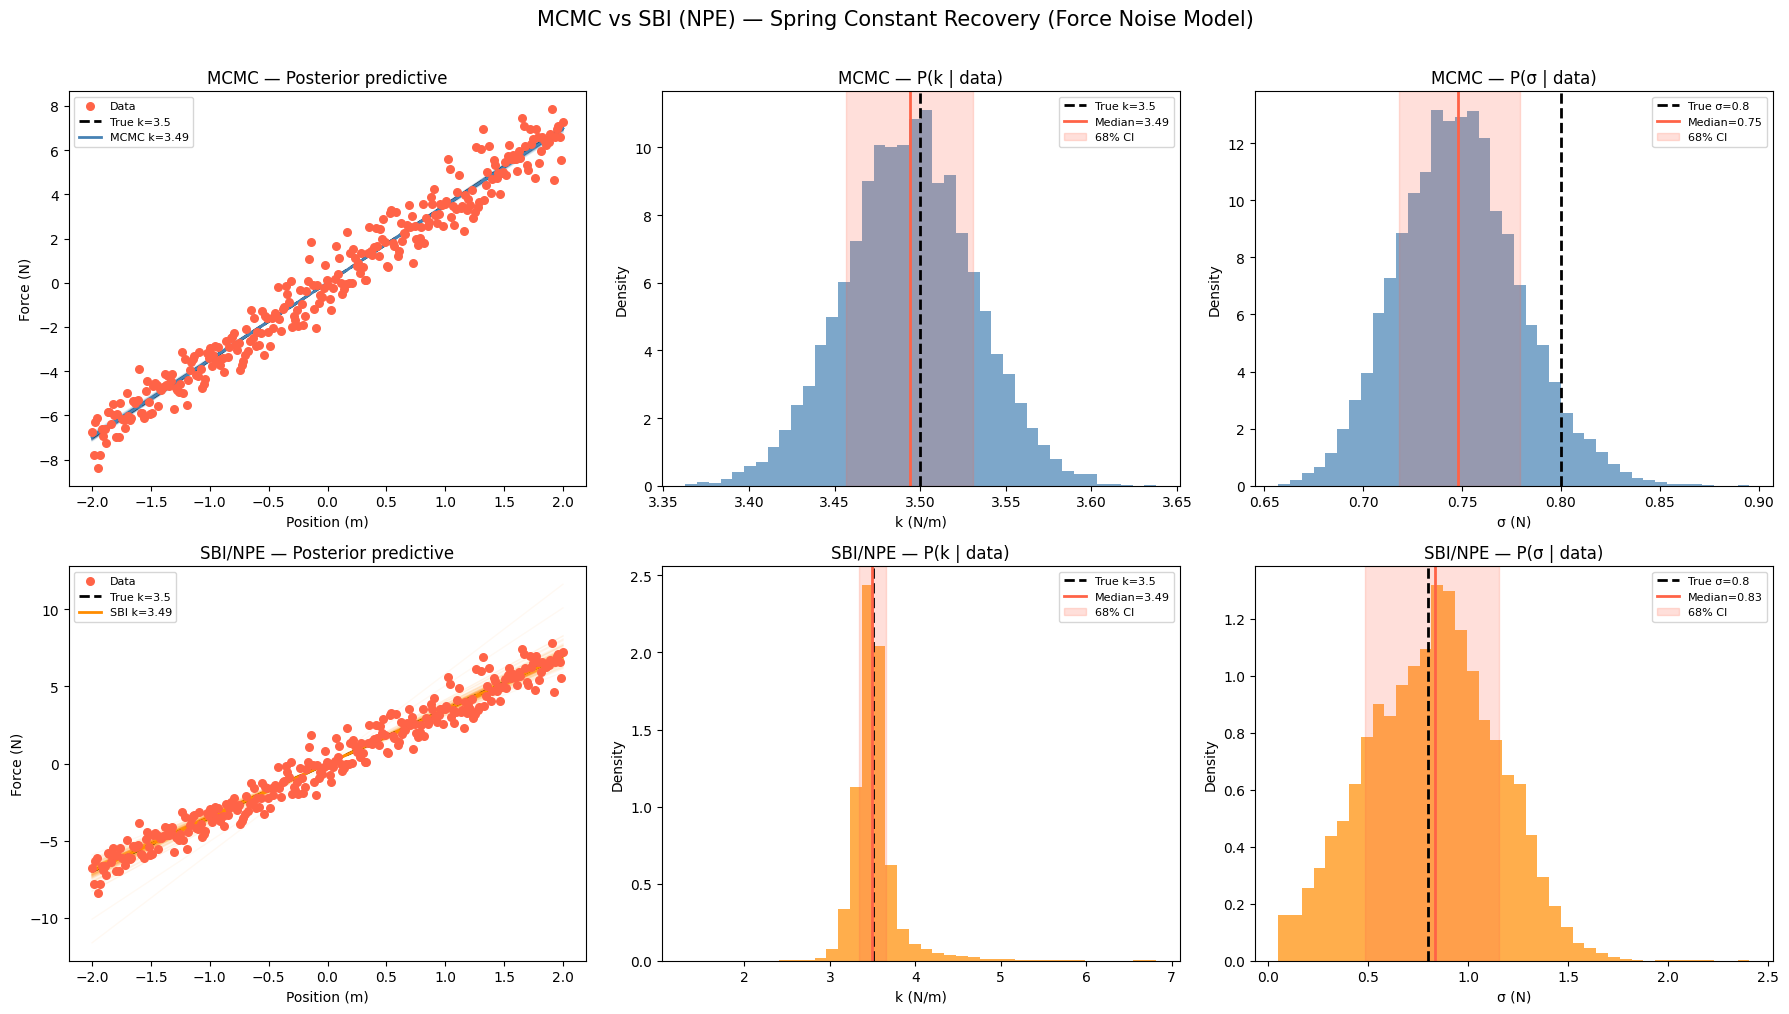

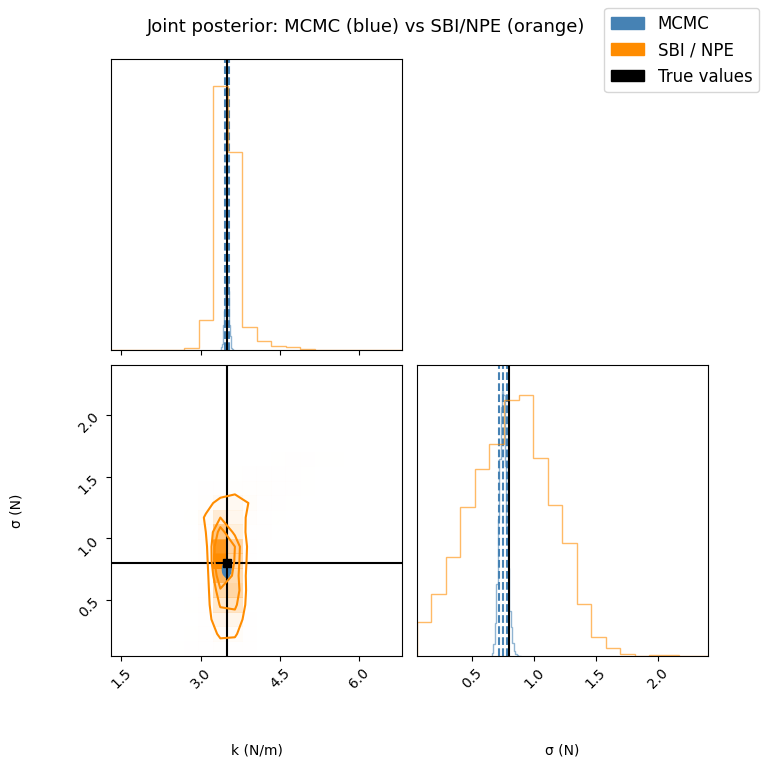


All plots saved.

── Final comparison (Force Noise Model) ────────────────────
Method       k median   σ median
True            3.500      0.800
MCMC            3.494      0.748
SBI/NPE         3.491      0.833


In [13]:
study = SpringInferenceComparison(n_points=300, n_simulations=10000, noise_std=0.8)
study.run_all()

Okay let's try to apply the same class on reduced data meaning data with some binning applied. The goal is to see how the algorithms perform by reducing the data size and changing the $\sigma$ accordingly